In [1]:
import ipdb
import json
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import seaborn as sns
import pandas as pd
import re
import warnings

from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings('ignore', category=MatplotlibDeprecationWarning)

plt.style.use(['science', 'bright'])

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 9,
    'font.family': 'serif',
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'figure.constrained_layout.use': True,
    'legend.frameon': True,
    'text.usetex': False,
})

# width of the thesis in points
WIDTH = 441.01775

# image saving format
IMG_FORMAT = 'pdf'

In [3]:
def set_size(width_pt, fraction=1, subplots=(1, 1), y_scale=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    
    if y_scale:
        fig_height_in = fig_height_in * y_scale

    return (fig_width_in, fig_height_in)

In [4]:
def get_figure(subplots, fraction=1.0, y_scale=False):
    figsize = set_size(WIDTH, fraction=fraction, subplots=subplots, y_scale=y_scale)
    print(f'figsize: {figsize}')
    fig, axes = plt.subplots(subplots[0], subplots[1], figsize=figsize, constrained_layout=True)

    return fig, axes

In [5]:
def read_json_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [6]:
def format_label(label):
    """ Replace underscores with spaces and capitalize the label """
    return label.replace('_', ' ').title()

# Accuracy comparison

In [7]:
def extract_info(data, target_dataset):
    results = {}
    for key, value in data.items():
        dataset_name = value['configuration']['dataset_name']
        subset_size = value['configuration']['subset_size']
        if dataset_name == target_dataset:
            model_name = ' '.join(key.split('_')[:2])  # Assuming model name is the first two parts
            peft_method = value['configuration']['peft'].capitalize()
            epsilon = value['hyperparameters']['target_epsilon']
            accuracy = float(value['best_value'])

            subset_key = f'{dataset_name} {subset_size*100:.0f}%'

            if subset_key not in results:
                results[subset_key] = {}
            if model_name not in results[subset_key]:
                results[subset_key][model_name] = {}
            if peft_method not in results[subset_key][model_name]:
                results[subset_key][model_name][peft_method] = {}
            results[subset_key][model_name][peft_method][epsilon] = accuracy
    return results


In [8]:
def plot_data(processed_data, dataset_name):
    num_subsets = len(processed_data)
    fig, axs = get_figure((num_subsets, 1))  # Assuming one column of subplots
    if num_subsets == 1:
        axs = [axs]

    for ax, (subset, models_data) in zip(axs, processed_data.items()):
        epsilons = sorted({ep for model_data in models_data.values() for method_data in model_data.values() for ep in method_data.keys()})
        pos = list(range(len(epsilons)))
        bar_width = 0.2

        for idx, (model, methods_data) in enumerate(models_data.items()):
            for jdx, (peft_method, eps_data) in enumerate(methods_data.items()):
                scores = [eps_data.get(ep, 0) for ep in epsilons]
                ax.bar([p + bar_width*(idx*len(methods_data) + jdx) for p in pos], scores, width=bar_width, label=f'{model} - {peft_method}')

        ax.set_ylabel('Accuracy')
        ax.set_title(f'Accuracy by Model, PEFT Method, and Epsilon ({subset})')
        ax.set_xticks([p + bar_width for p in pos])
        ax.set_xticklabels(epsilons)
        ax.legend()

    plt.show()

figsize: (6.102362667773626, 3.771467540362584)


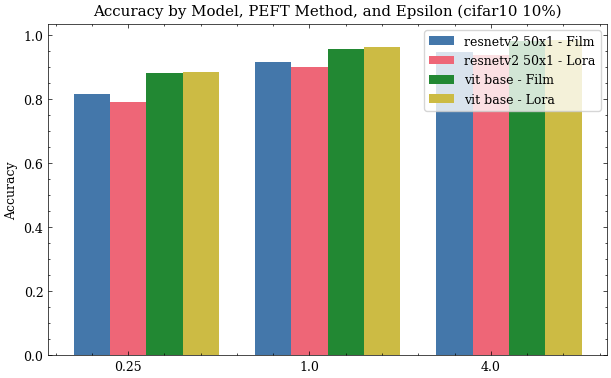

figsize: (6.102362667773626, 7.542935080725168)


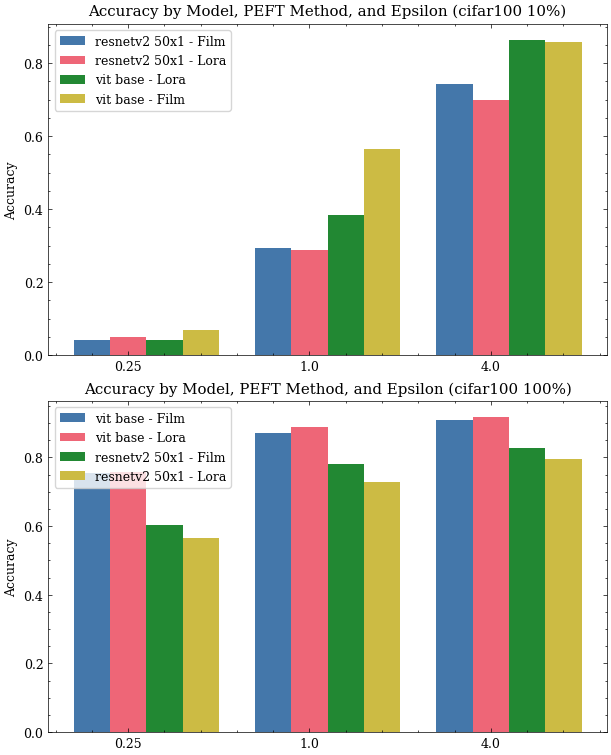

In [9]:
file_path = '../processed-data/aggregated_data.json'
data = read_json_data(file_path)
for dataset in ['cifar10', 'cifar100']:
    processed_data = extract_info(data, dataset)
    plot_data(processed_data, dataset)

# Accuracy heatmaps

In [10]:
def prepare_heatmap_data(data, target_dataset):
    df_list = []
    for key, value in data.items():
        dataset_name = value['configuration']['dataset_name']
        subset_size = value['configuration']['subset_size']
        if dataset_name == target_dataset:
            model_name = ' '.join(key.split('_')[:2])
            peft_method = value['configuration']['peft'].capitalize()
            epsilon = value['hyperparameters']['target_epsilon']
            accuracy = float(value['best_value'])
            df_list.append({'Model': model_name, 'PEFT Method': peft_method, 'Epsilon': epsilon, 'Accuracy': accuracy, 'Subset Size': f'{subset_size*100:.0f}%'})
    return pd.DataFrame(df_list)

def plot_heatmap(df, dataset_name, subset_size):
    # Modifying the 'Model' column to include PEFT method
    df['Model'] = df['Model'] + ' - ' + df['PEFT Method']

    # Creating the pivot table
    heatmap_data = df.pivot(index='Model', columns='Epsilon', values='Accuracy')

    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(f'Accuracy Heatmap for {dataset_name.upper()} {subset_size} Subset')
    plt.show()

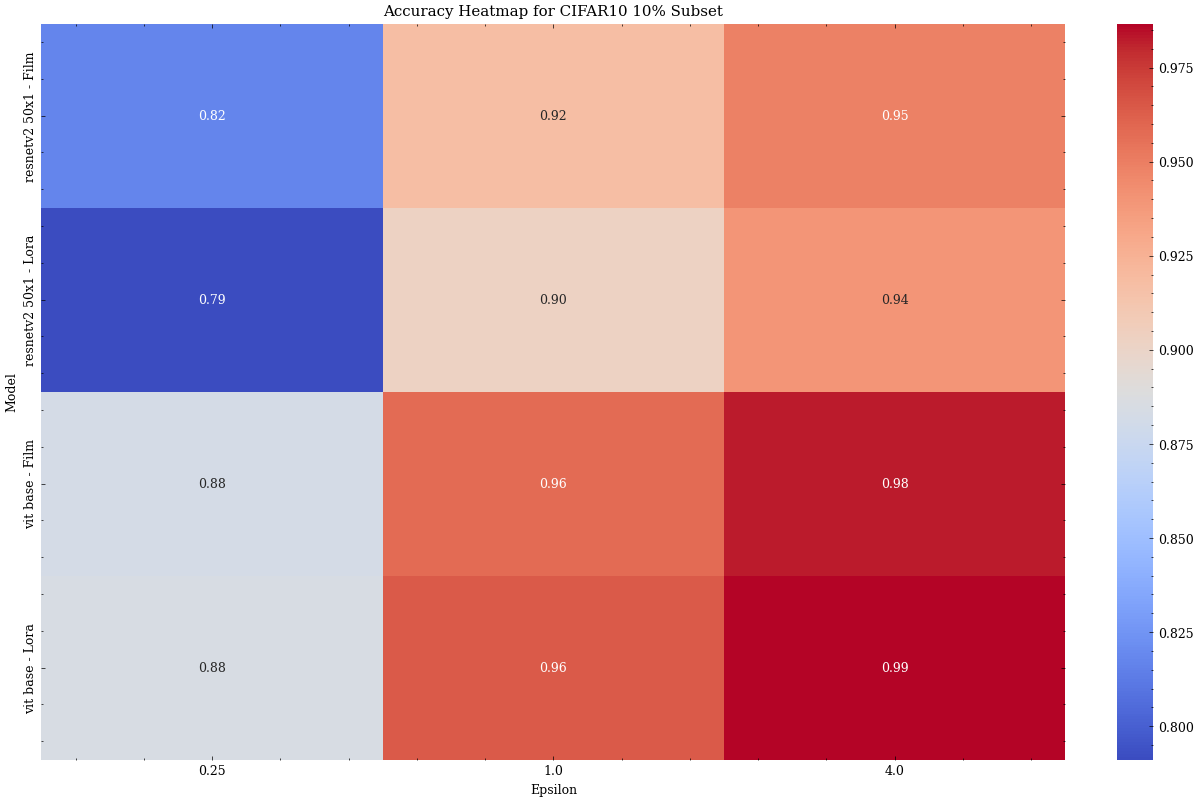

/tmp/ipykernel_1771308/3291906066.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Model'] = df['Model'] + ' - ' + df['PEFT Method']


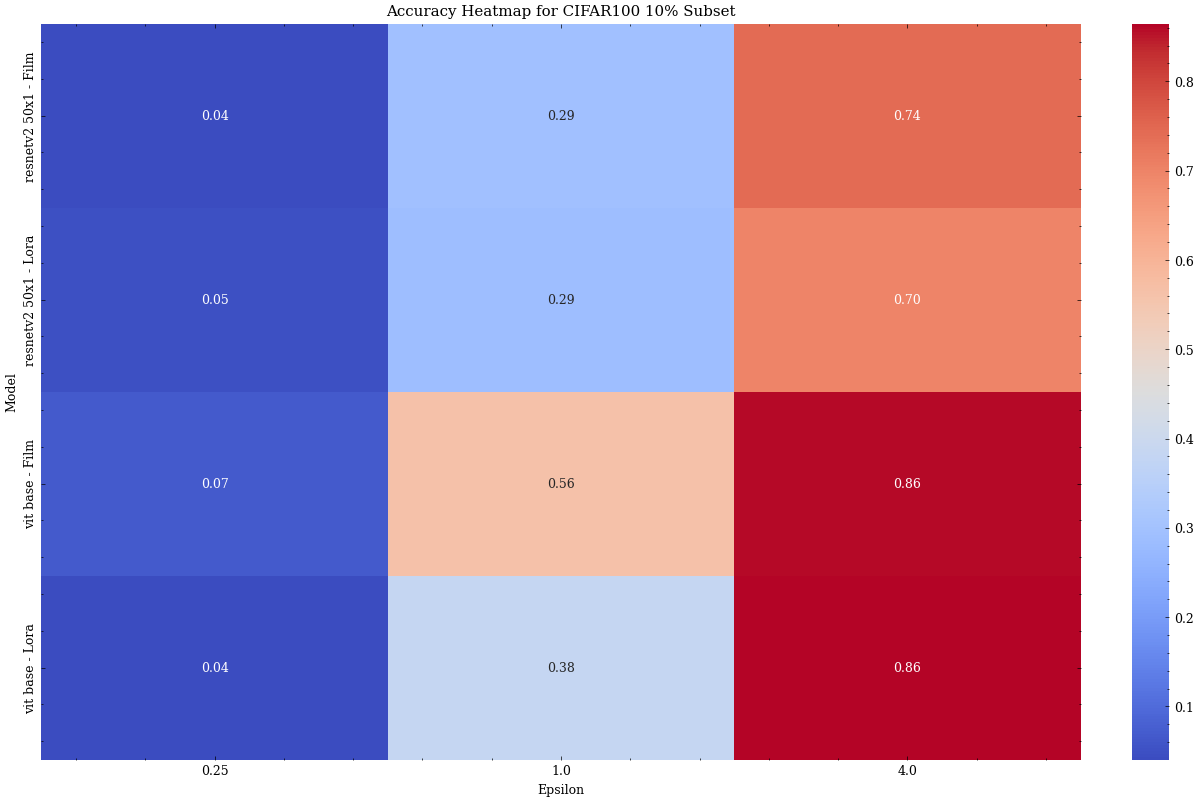

/tmp/ipykernel_1771308/3291906066.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Model'] = df['Model'] + ' - ' + df['PEFT Method']


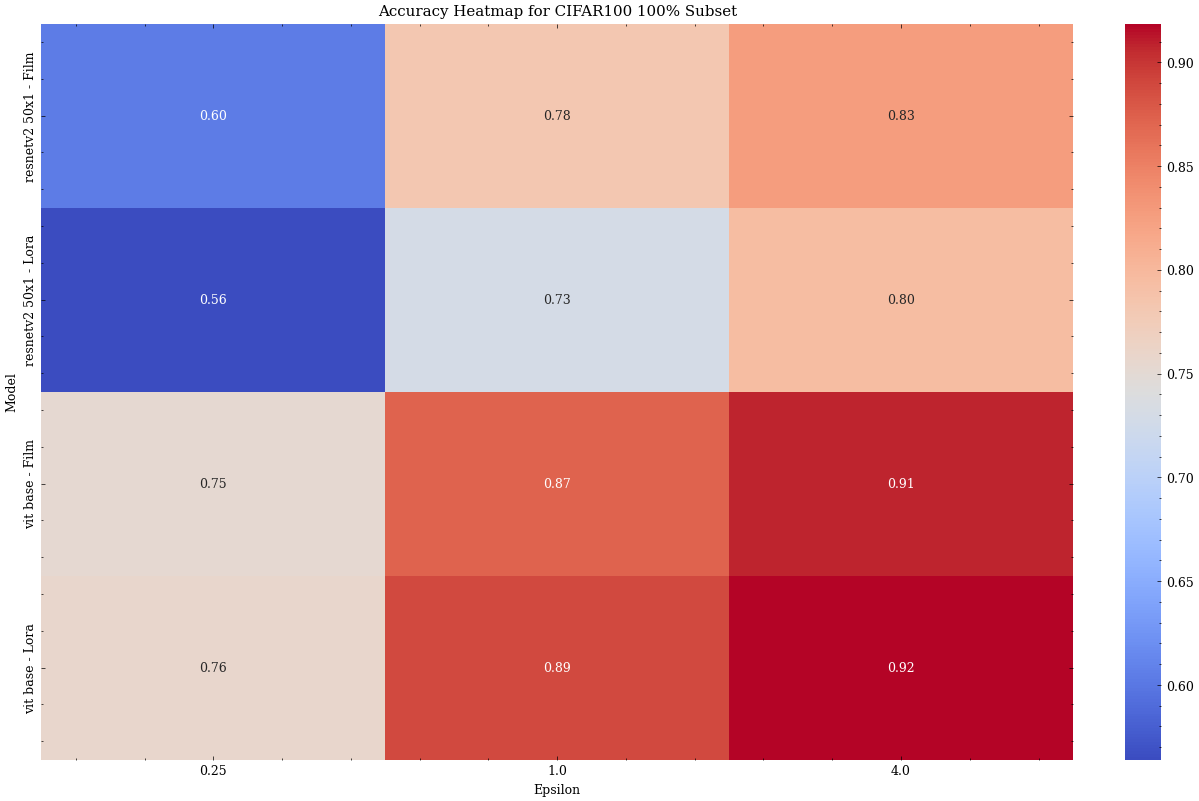

In [11]:
file_path = '../processed-data/aggregated_data.json'
data = read_json_data(file_path)

for dataset in ['cifar10', 'cifar100']:
    df = prepare_heatmap_data(data, dataset)
    for subset_size in df['Subset Size'].unique():
        subset_df = df[df['Subset Size'] == subset_size]
        plot_heatmap(subset_df, dataset, subset_size)

# Line Graphs for Accuracy Trends

In [12]:
def prepare_line_graph_data(data, target_dataset):
    df_list = []
    for key, value in data.items():
        dataset_name = value['configuration']['dataset_name']
        subset_size = value['configuration']['subset_size']
        if dataset_name == target_dataset:
            model_name = ' '.join(key.split('_')[:2])
            peft_method = value['configuration']['peft'].capitalize()
            epsilon = value['hyperparameters']['target_epsilon']
            accuracy = float(value['best_value'])
            df_list.append({'Model': model_name, 'PEFT Method': peft_method, 'Epsilon': epsilon, 'Accuracy': accuracy, 'Subset Size': f'{subset_size*100:.0f}%'})
    return pd.DataFrame(df_list)

def plot_accuracy_trends(df, dataset_name, subset_size):
    plt.figure(figsize=(10, 6))
    unique_combinations = df[['Model', 'PEFT Method']].drop_duplicates()
    for _, row in unique_combinations.iterrows():
        model, peft_method = row['Model'], row['PEFT Method']
        subset_df = df[(df['Model'] == model) & (df['PEFT Method'] == peft_method)]
        subset_df = subset_df.sort_values(by='Epsilon')  # Sorting by Epsilon
        epsilons = subset_df['Epsilon'].tolist()  # Convert to list
        accuracies = subset_df['Accuracy'].tolist()  # Convert to list
        plt.plot(epsilons, accuracies, marker='o', label=f'{model} - {peft_method}')

    plt.ylim([0, 1])
    plt.xlabel('Epsilon')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Trends for {dataset_name.upper()} {subset_size} Subset')
    plt.legend()
    plt.show()

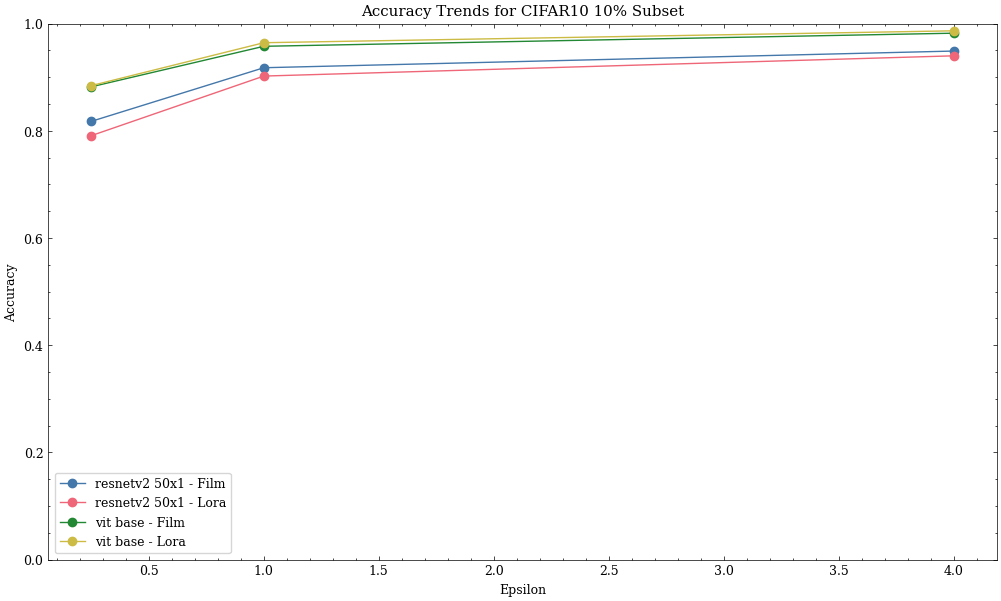

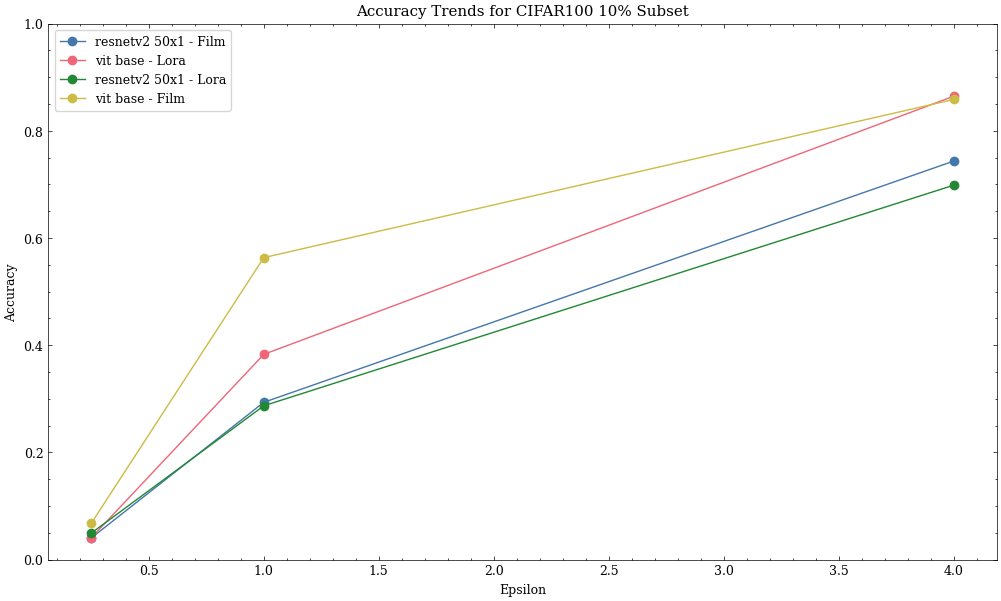

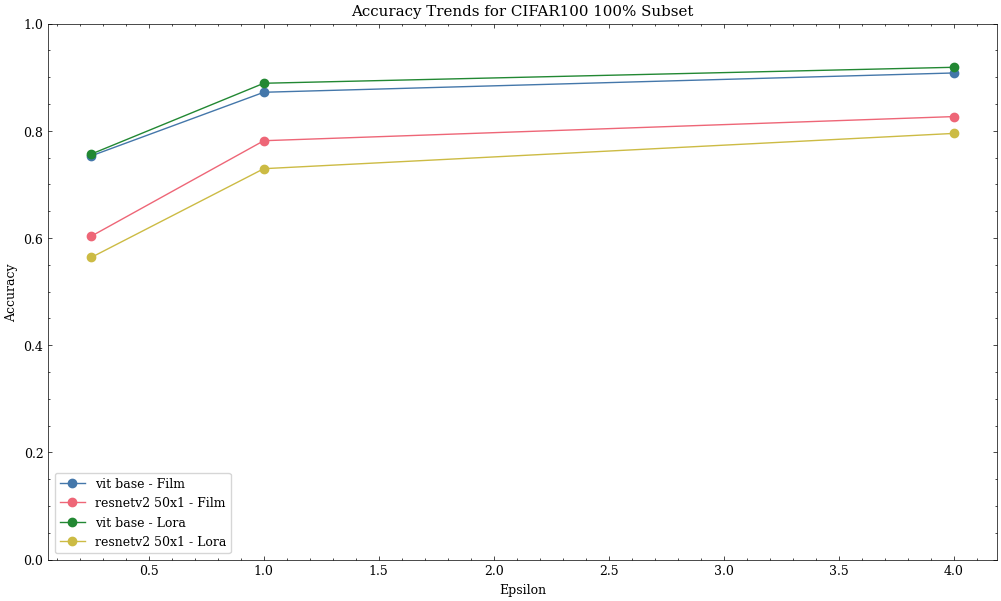

In [13]:
file_path = '../processed-data/aggregated_data.json'
data = read_json_data(file_path)

for dataset in ['cifar10', 'cifar100']:
    df = prepare_line_graph_data(data, dataset)
    for subset_size in df['Subset Size'].unique():
        subset_df = df[df['Subset Size'] == subset_size]
        plot_accuracy_trends(subset_df, dataset, subset_size)

# 20 Trials vs 50 Trials, 10% subset

In [14]:
def prepare_data(data, target_dataset, subset_size_filter=None):
    df_list = []
    for key, value in data.items():
        dataset_name = value['configuration']['dataset_name']
        subset_size = value['configuration']['subset_size']
        if dataset_name == target_dataset and (subset_size_filter is None or subset_size == subset_size_filter):
            model_name = ' '.join(key.split('_')[:2])
            peft_method = value['configuration']['peft'].capitalize()
            epsilon = value['hyperparameters']['target_epsilon']
            accuracy = float(value['best_value'])
            n_trials = value['configuration']['n_trials']
            df_list.append({'Model': model_name, 'PEFT Method': peft_method, 'Epsilon': epsilon, 'Accuracy': accuracy, 'Subset Size': f'{subset_size*100:.0f}%', 'N Trials': n_trials})
    return pd.DataFrame(df_list)

def plot_model_peft_comparison_bar_chart(df, dataset_name, model, peft_method):
    unique_epsilons = sorted(df['Epsilon'].unique())
    fig, ax = get_figure((1, 1))

    bar_width = 0.35
    index = np.arange(len(unique_epsilons))

    for idx, n_trials in enumerate(sorted(df['N Trials'].unique())):
        trial_df = df[(df['Model'] == model) & (df['PEFT Method'] == peft_method) & (df['N Trials'] == n_trials)]
        accuracies = [trial_df[trial_df['Epsilon'] == ep]['Accuracy'].values[0] if not trial_df[trial_df['Epsilon'] == ep].empty else 0 for ep in unique_epsilons]
        ax.bar(index + idx * bar_width, accuracies, bar_width, label=f'{n_trials} Trials')

    ax.set_xlabel('Epsilon')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy Comparison for {model} - {peft_method} in {dataset_name.upper()}')
    ax.set_xticks(index + bar_width * (len(df['N Trials'].unique()) - 1) / 2)
    ax.set_xticklabels(unique_epsilons)
    ax.legend()
    plt.show()


In [15]:
def plot():
    file_path = '../processed-data/aggregated_data.json'
    data = read_json_data(file_path)

    for dataset in ['cifar10', 'cifar100']:
        df = prepare_data(data, dataset, subset_size_filter=0.1)
        for model in df['Model'].unique():
            for peft_method in df['PEFT Method'].unique():
                plot_model_peft_comparison_bar_chart(df, dataset, model, peft_method)


figsize: (6.102362667773626, 3.771467540362584)


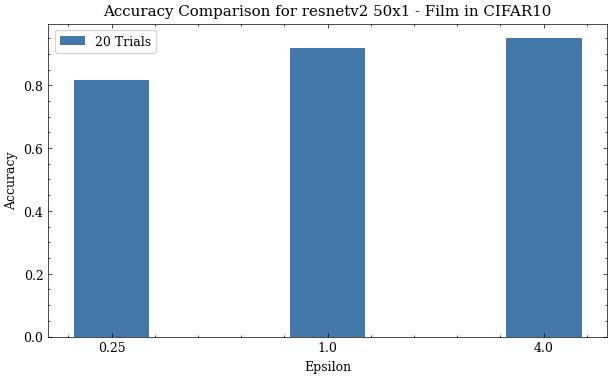

figsize: (6.102362667773626, 3.771467540362584)


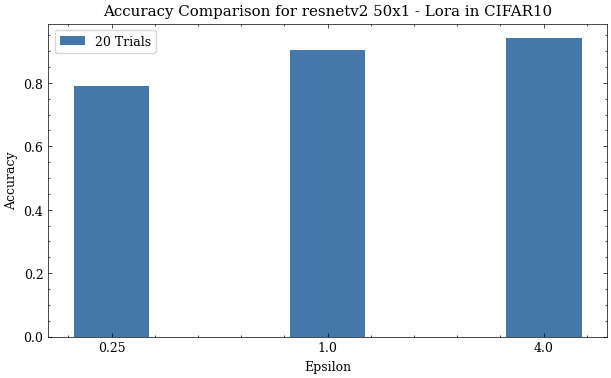

figsize: (6.102362667773626, 3.771467540362584)


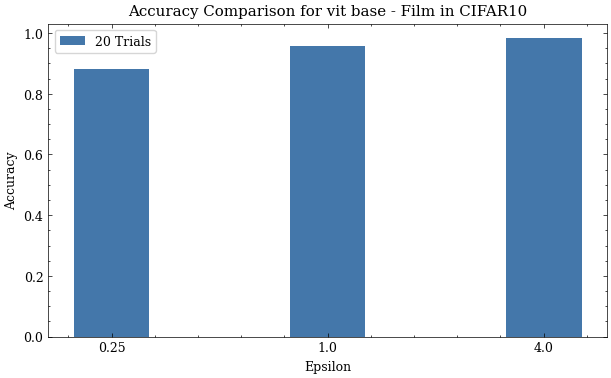

figsize: (6.102362667773626, 3.771467540362584)


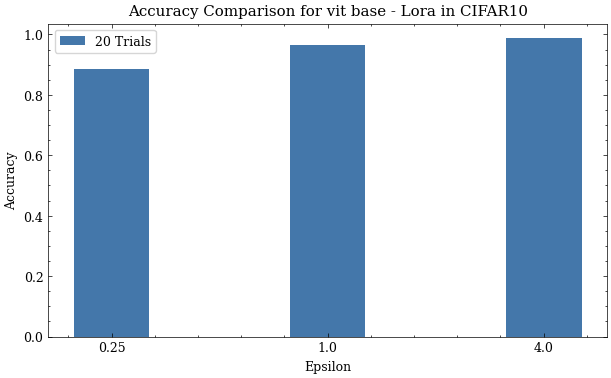

figsize: (6.102362667773626, 3.771467540362584)


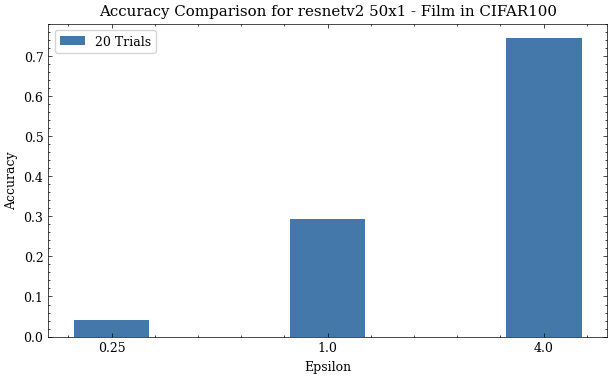

figsize: (6.102362667773626, 3.771467540362584)


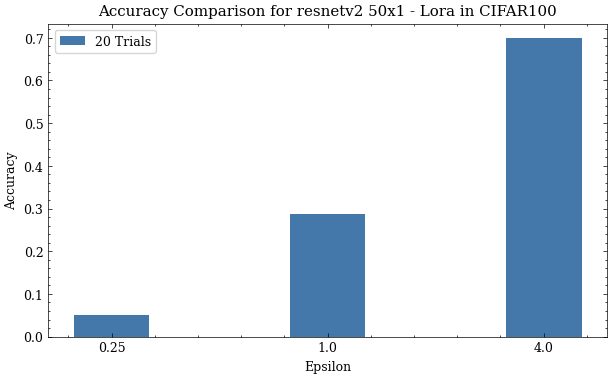

figsize: (6.102362667773626, 3.771467540362584)


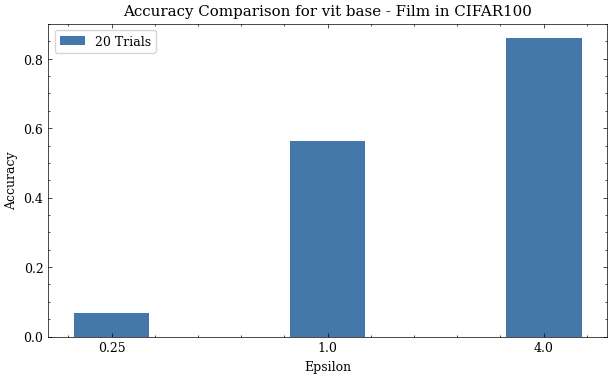

figsize: (6.102362667773626, 3.771467540362584)


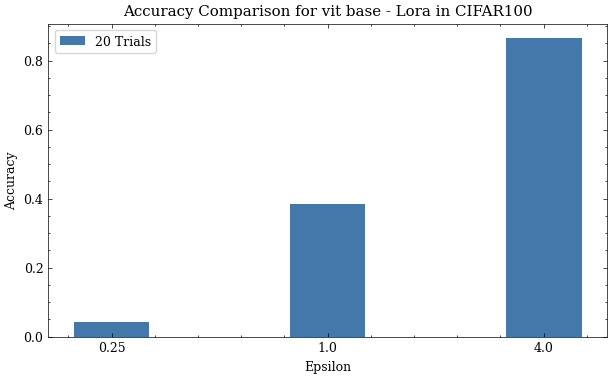

In [16]:
plot()

# Hyperparameter comparison for cifar100 10% subset vs cifar100 100% subset

## Try 2

In [17]:
def prepare_hyperparameters_data(data):
    rows = []
    for experiment_name, details in data.items():
        model_name = details['configuration']['model_name']
        peft = details['configuration']['peft']
        subset_size = details['configuration']['subset_size']
        dataset = details['configuration']['dataset_name']
        best_params = details['best_params']
        epsilon = details['hyperparameters']['target_epsilon']

        if dataset != 'cifar100':
            continue

        row = {
            'experiment_name': experiment_name,
            'model_name': model_name,
            'peft': peft,
            'subset_size': subset_size,
            'dataset': dataset,
            'epsilon': epsilon,
            **best_params
        }
        rows.append(row)

    return pd.DataFrame(rows)

def plot_hyperparameters_trends(df, hyperparameter, rows, cols):
    fig, axs = get_figure((rows, cols))
    axs = axs.ravel()
    ax_idx = 0

    for (epsilon, peft), group in df.groupby(['epsilon', 'peft']):
        ax = axs[ax_idx]

        for model in group['model_name'].unique():
            model_group = group[group['model_name'] == model]

            # Extract data for 10% and 100% subsets
            data_10 = model_group[model_group['subset_size'] == 0.1]
            data_100 = model_group[model_group['subset_size'] == 1.0]

            if not data_10.empty and not data_100.empty:
                # Plotting the two points and connecting them
                ax.plot([0.1, 1.0], [data_10[hyperparameter].values[0], data_100[hyperparameter].values[0]], 
                        marker='o', linestyle='-', label=model)

        formatted_hyperparameter = format_label(hyperparameter)
        ax.set_title(f'{formatted_hyperparameter} - Epsilon: {epsilon}, PEFT: {peft}')
        ax.set_ylabel(formatted_hyperparameter)
        ax.set_xlabel('Subset Size')
        ax.set_xticks([0.1, 1.0])
        ax.set_xticklabels(['10%', '100%'])

        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        ax_idx += 1

    plt.tight_layout()
    plt.show()


In [18]:
def plot():
    file_path = '../processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    df = prepare_hyperparameters_data(data)
    for hyperparameter in ['epochs', 'batch_size', 'learning_rate', 'max_grad_norm']:
        # Define the number of rows and columns for subplots
        rows, cols = 6, 1
        plot_hyperparameters_trends(df, hyperparameter, rows, cols)

figsize: (6.102362667773626, 22.628805242175503)


/tmp/ipykernel_1771308/3934814407.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


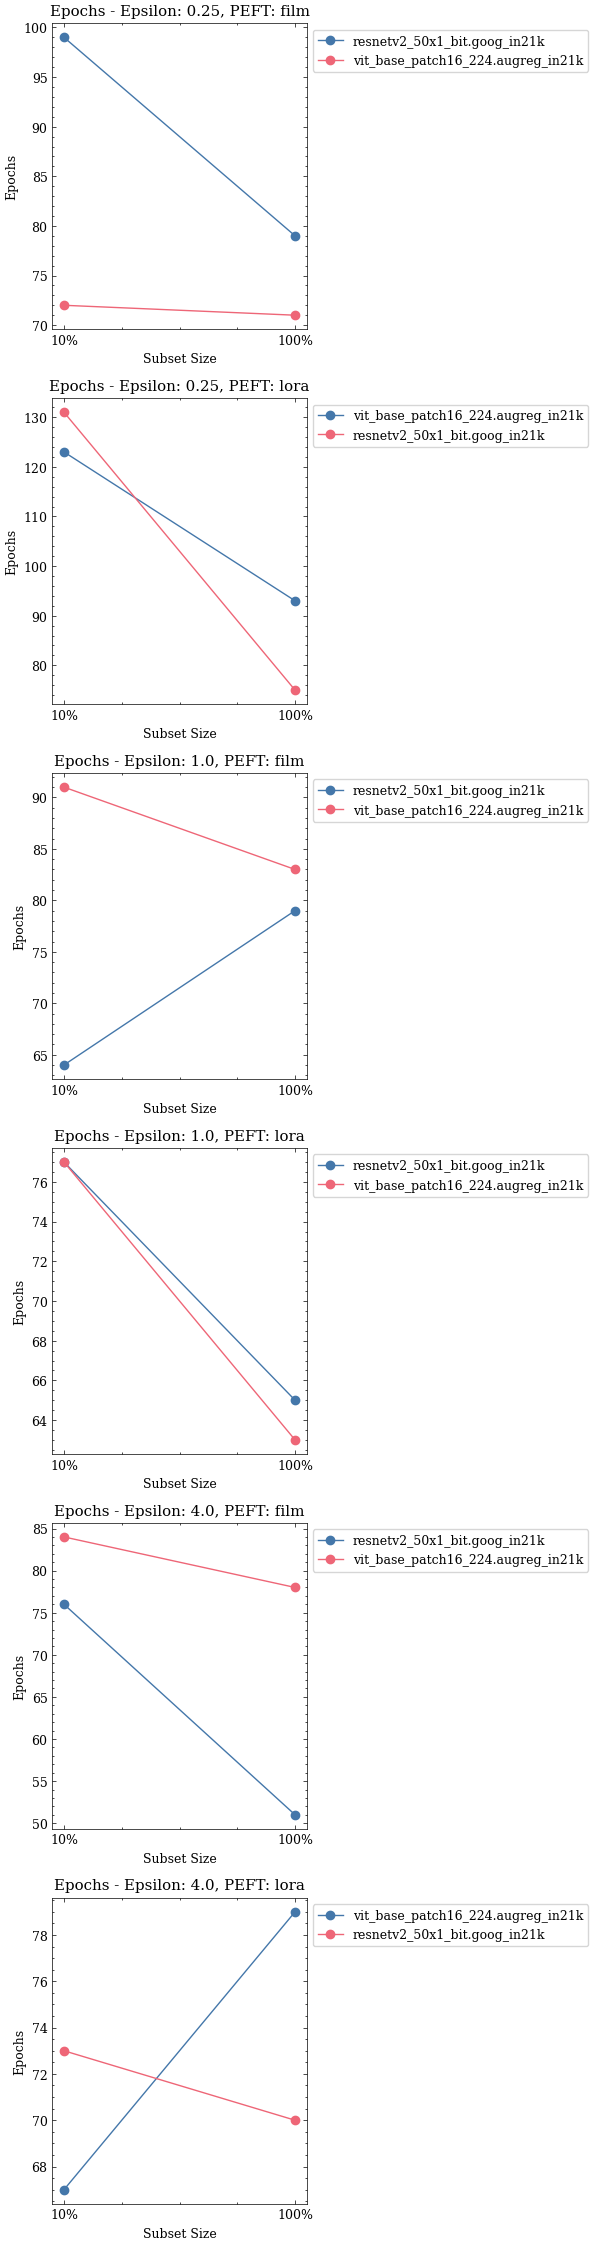

figsize: (6.102362667773626, 22.628805242175503)


/tmp/ipykernel_1771308/3934814407.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


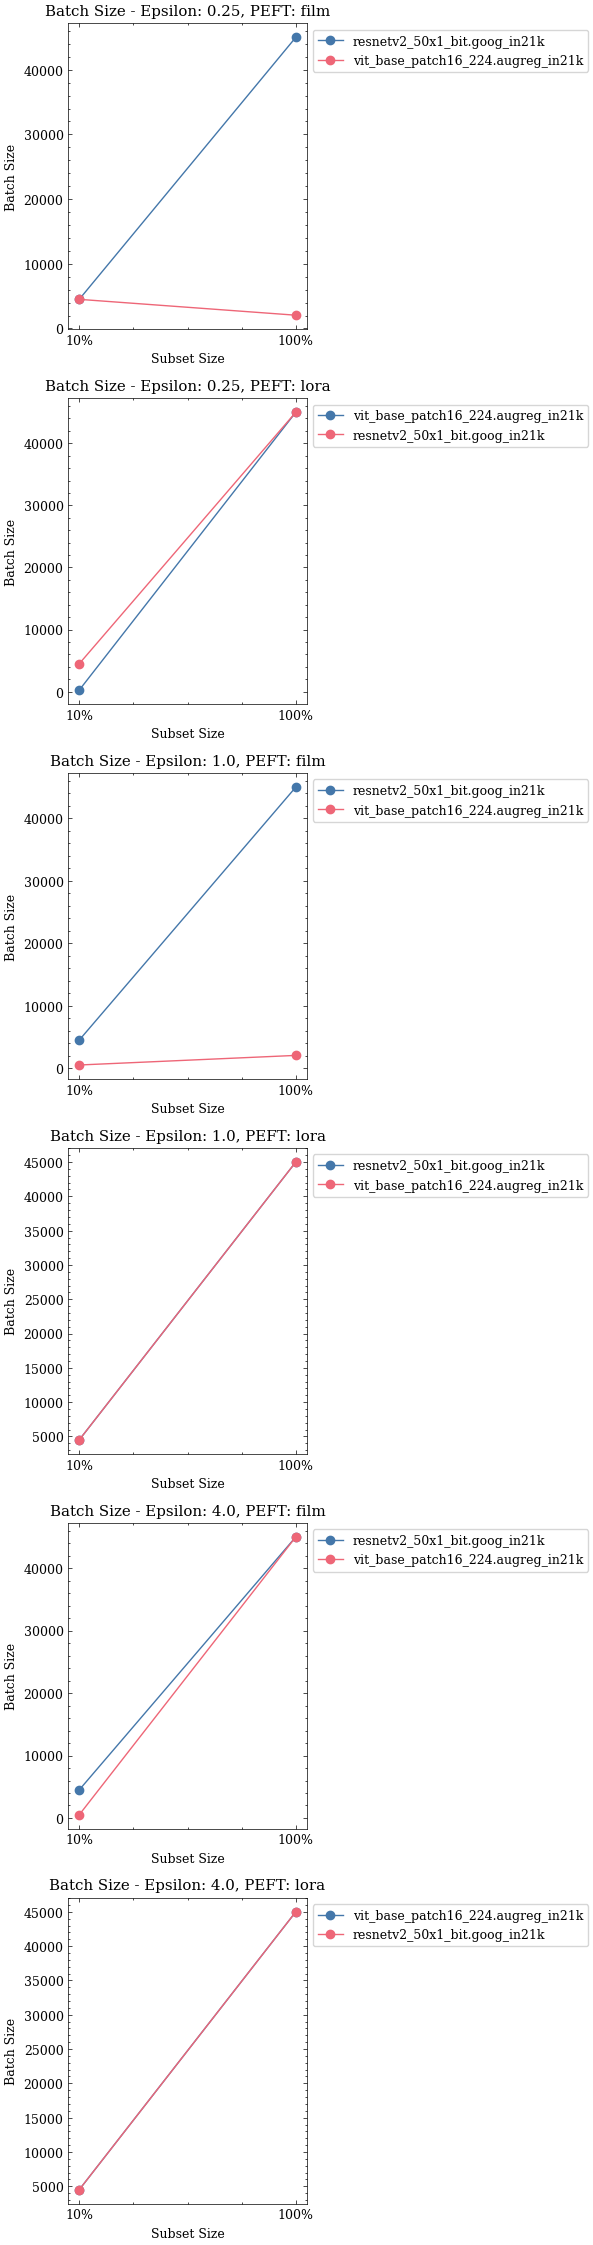

figsize: (6.102362667773626, 22.628805242175503)


/tmp/ipykernel_1771308/3934814407.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


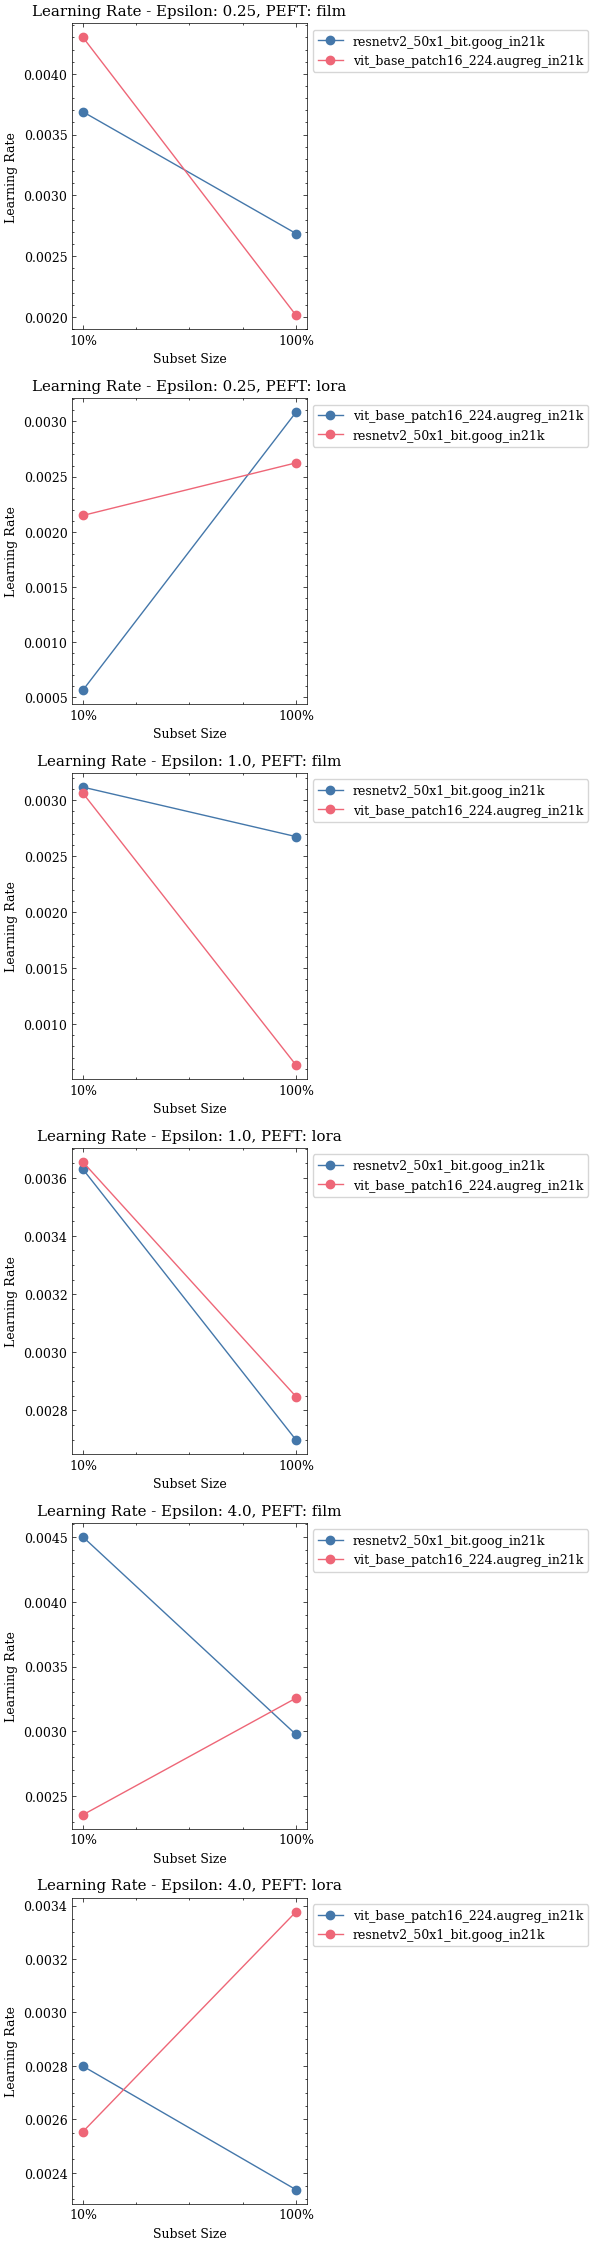

figsize: (6.102362667773626, 22.628805242175503)


/tmp/ipykernel_1771308/3934814407.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


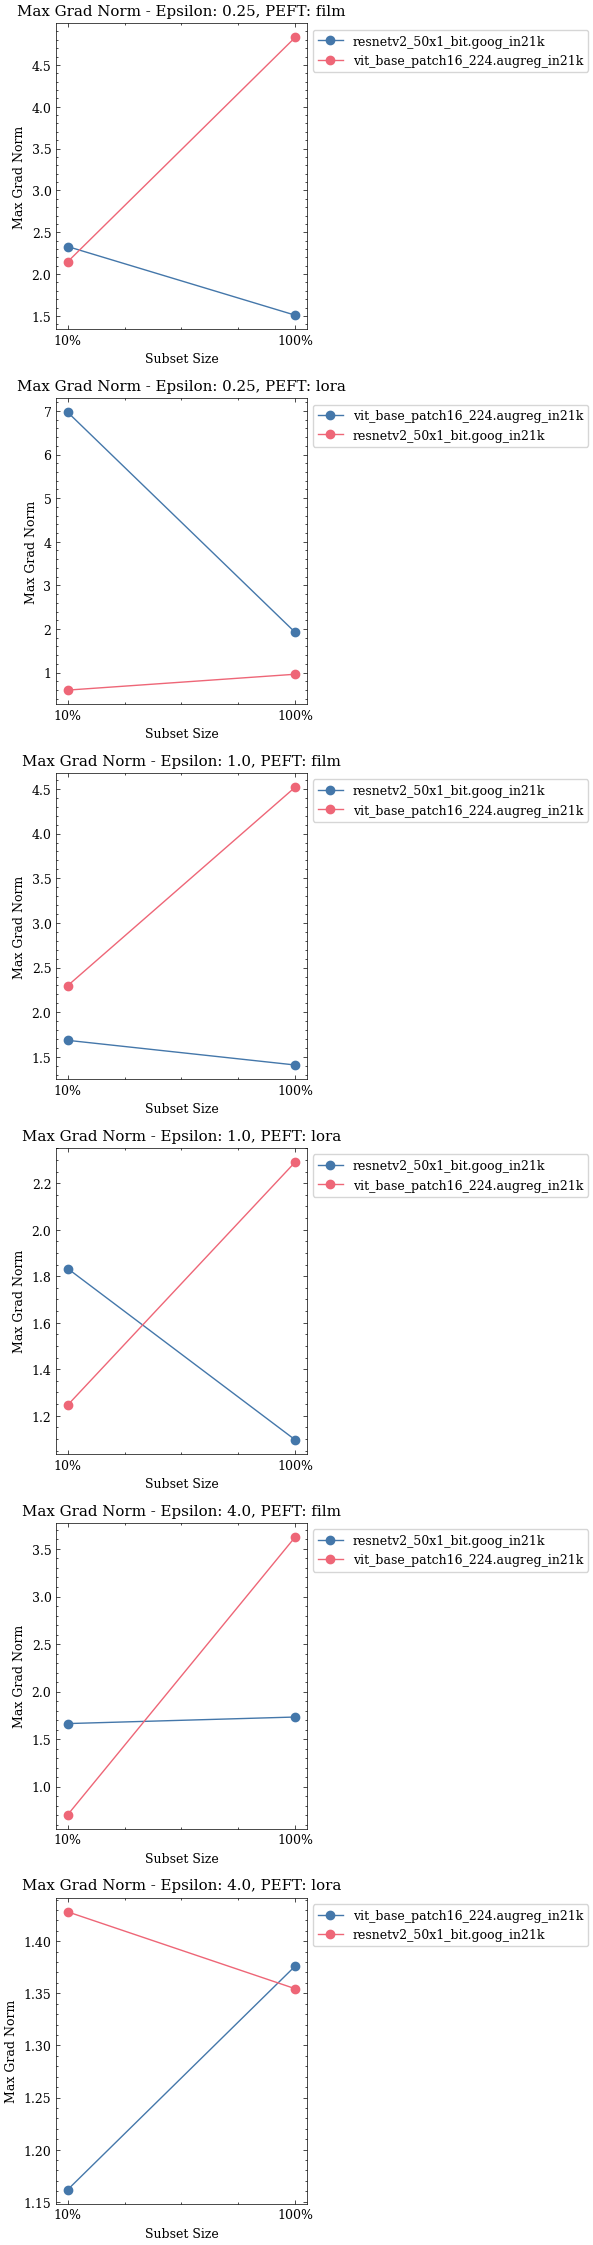

In [19]:
plot()